In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFE, RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score, auc
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import numpy as np

In [29]:
file_names = {
    'sissi_oversampling': 'D:/Masterarbeit_programmieren/Data/SISSIz_Data_di_Excel/sissi_oversampling.xlsx',
    'sissiz_mono': 'D:/Masterarbeit_Daten/Data/SISSIz_Data_di_Excel/sissiz_mono.xlsx'
}

In [30]:
# Leerer DataFrame für die Daten
df = pd.DataFrame()

# Excel-Dateien laden
for name, file_path in file_names.items():
    try:
        df[name] = pd.read_excel(file_path)['z-score calculated from 7. 8. and 9.']
    except Exception as e:
        print(f"Fehler beim Laden von {name}: {e}")


In [31]:
# sissi_oversampling = df['sissi_oversampling']
# multiperm_mono = df['sissiz_mono']

# labels_sissi = np.zeros(len(sissi_oversampling))
# labels_multiperm = np.ones(len(sissiz_mono))

# data = pd.concat([sissi_oversampling, multiperm_mono], axis=0)
# labels = np.concatenate([labels_sissi, labels_multiperm])

In [32]:
def receiverOperationCharacteristics(x, y, z):
    # Beispiel-Daten
    positive_file = x.astype(float)  # Positive Control Set
    negative_file = y.astype(float)  # Negative Control Set

    # Labels für positive und negative Daten erstellen
    positive_labels = np.ones(len(positive_file))
    negative_labels = np.zeros(len(negative_file))

    # Daten und Labels zusammenführen
    data = pd.concat([positive_file, negative_file], axis=0)
    labels = np.concatenate([positive_labels, negative_labels])

    # ROC-Kurve berechnen
    fpr, tpr, thresholds = roc_curve(labels, data)

    # AUC berechnen
    auc_score = auc(fpr, tpr)

    # ROC-Kurve plotten
    plt.plot(fpr, tpr, label='ROC curve (AUC = %0.2f)' % auc_score)
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(z)
    plt.legend(loc="upper left")
    plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df[['sissi_oversampling']], df[['sissiz_mono']], test_size=0.3, random_state=42)
print("X_train: " + str(X_train.shape))
print("y_train: " + str(y_train.shape))
print("X_test: " + str(X_test.shape))
print("y_test: " + str(y_test.shape))

print('--------------')
print(y_train)
print('--------------')

# Reshape der Eingabevariablen
X_train = X_train.values.reshape(-1, 1)
X_test = X_test.values.reshape(-1, 1)

# Logistische Regression durchführen
model = LogisticRegression(max_iter=100000)
model.fit(X_train, y_train)

# Vorhersagen auf dem Testdatensatz machen
y_pred = model.predict(X_test)

X_train: (70000, 1)
y_train: (70000, 1)
X_test: (30000, 1)
y_test: (30000, 1)


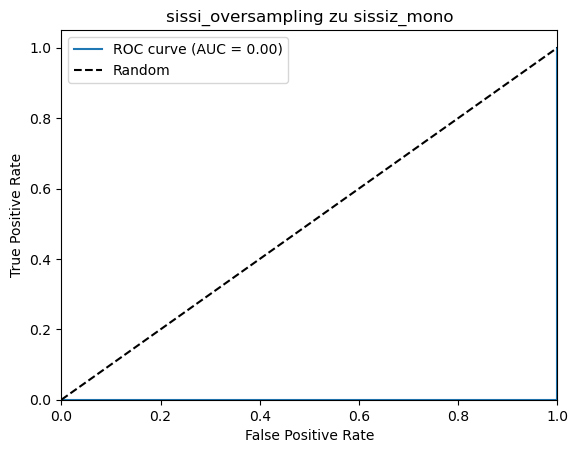

In [38]:
positive_file = df['sissi_oversampling']
negative_file = df['sissiz_mono']  # entsprechende Spalte für negatives Control Set
title = f"sissi_oversampling zu sissiz_mono"
receiverOperationCharacteristics(positive_file, negative_file, title)